Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)

Training Discriminative Model...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8974 - loss: 0.3745 - val_accuracy: 0.9547 - val_loss: 0.1725
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9487 - loss: 0.1794 - val_accuracy: 0.9638 - val_loss: 0.1261
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9629 - loss: 0.1298 - val_accuracy: 0.9730 - val_loss: 0.1081

Discriminative Model Accuracy: 0.9653000235557556

Training Generative Model...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0455 - val_loss: 0.0233
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0192 - val_loss: 0.0162
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0147 - val_loss: 0.0133


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


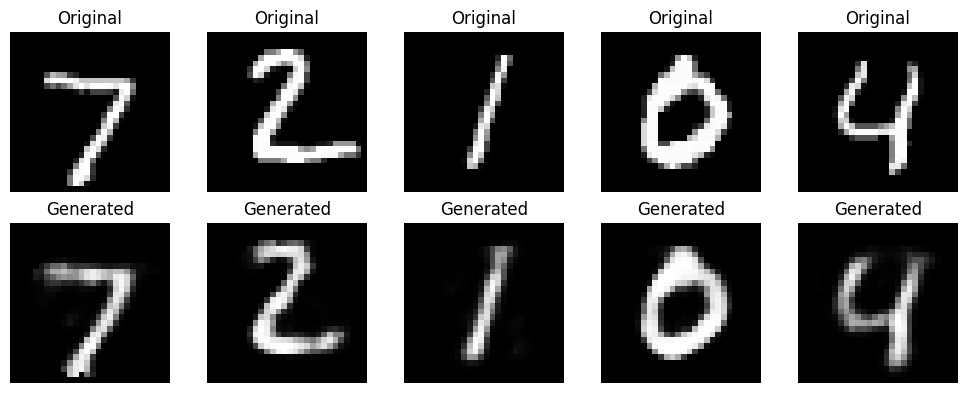

In [ ]:
# from tensorflow.keras.datasets import mnist
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Flatten, Reshape

# (x,y),(X,Y)=mnist.load_data()
# x,X=x/255.,X/255.

# # Discriminative: Classify
# d=Sequential([Flatten(input_shape=(28,28)),Dense(10,'softmax')])
# d.compile('adam','sparse_categorical_crossentropy',metrics=['accuracy'])
# d.fit(x,y,epochs=1)

# # Generative: Reconstruct
# g=Sequential([Flatten(input_shape=(28,28)),Dense(64,'relu'),Dense(784,'sigmoid'),Reshape((28,28))])
# g.compile('adam','mse')
# g.fit(x,x,epochs=1)

# print("Discriminative:",d.predict(X[:10]).argmax(axis=1))

# print("Generative: reconstructed image created")

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape

# --------------------------------------------------
# 1. Load MNIST Dataset
# --------------------------------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values: 0-255 -> 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)


# --------------------------------------------------
# 2. Discriminative Model - Classification
# --------------------------------------------------

classifier = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining Discriminative Model...")

classifier.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

loss, accuracy = classifier.evaluate(x_test, y_test, verbose=0)

print("\nDiscriminative Model Accuracy:", accuracy)


# --------------------------------------------------
# 3. Generative Model - Autoencoder
# --------------------------------------------------

autoencoder = Sequential([
    Flatten(input_shape=(28, 28)),

    # Encoder
    Dense(128, activation="relu"),
    Dense(32, activation="relu"),

    # Decoder
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid"),

    Reshape((28, 28))
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

print("\nTraining Generative Model...")

autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)


# --------------------------------------------------
# 4. Image Reconstruction
# --------------------------------------------------

reconstructed = autoencoder.predict(x_test[:5])


# --------------------------------------------------
# 5. Display Original and Reconstructed Images
# --------------------------------------------------

plt.figure(figsize=(10, 4))

for i in range(5):

    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstructed Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i], cmap="gray")
    plt.axis("off")
    plt.title("Generated")

plt.tight_layout()
plt.show()